# Gradient Boosting

## Overview
Gradient Boosting is an ensemble machine learning technique that builds models sequentially.  
Each new model learns to correct the errors (residuals) made by the previous model.

It combines many weak learners (usually decision trees) to produce a strong predictive model.

Algorithm: Gradient Boosting

---

## Key Idea
Instead of training models independently, each new model focuses on the mistakes of the previous model.

Final model:

F(x) = F0(x) + ηh1(x) + ηh2(x) + ... + ηhn(x)

Where:
- F0(x) = initial prediction
- h(x) = weak learner (decision tree)
- η = learning rate

---

## Steps of Gradient Boosting

1. Initialize model with mean of target values.
2. Compute residuals (errors).

   Residual = Actual − Prediction

3. Train a weak learner to predict residuals.
4. Update predictions.

   New Prediction = Old Prediction + Learning Rate × Tree Output

5. Repeat steps 2–4 for multiple iterations.

---

## Simple Example

| X | Actual Y | Initial Prediction | Residual |
|---|---|---|---|
|1|2|4|-2|
|2|4|4|0|
|3|5|4|1|
|4|4|4|0|
|5|5|4|1|

A decision tree is trained to predict the residuals and improve the model.

---

## Important Parameters

- Learning Rate
- Number of Trees
- Tree Depth
- Loss Function

---

## Advantages

- High predictive accuracy
- Handles complex relationships
- Works well for structured/tabular data

---

## Disadvantages

- Training can be slow
- Sensitive to hyperparameters
- Can overfit if too many trees are used

---

## Popular Implementations

- XGBoost
- LightGBM
- CatBoost

---

## Interview One-Line Summary

Gradient Boosting is an ensemble technique where models are built sequentially, and each new model learns the residual errors of the previous model to minimize the loss function using gradient descent.

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [5]:
# Sample dataset: hours studied vs score
data = {
    "hours_studied": [1,2,3,4,5,6,7,8,9,10],
    "score": [50,55,65,70,75,78,85,88,90,95]
}

df = pd.DataFrame(data)
df

,hours_studied,score
0,1,50
1,2,55
2,3,65
3,4,70
4,5,75
5,6,78
6,7,85
7,8,88
8,9,90
9,10,95


In [6]:
X = df[["hours_studied"]]  # Feature
y = df["score"]            # Target

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 8
Test size: 2


In [8]:
# Initialize model
model = GradientBoostingRegressor(
    n_estimators=100,   # number of trees
    learning_rate=0.1,  # step size for updates
    max_depth=3,        # max depth of each tree
    random_state=42
)

# Train model
model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [9]:
predictions = model.predict(X_test)

# Show predictions vs actual
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})
results

,Actual,Predicted
8,90,87.999596
1,55,50.000684


In [10]:
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 14.497388637890637
R² Score: 0.9526615881211734


In [11]:
# Predict score for 6.5 hours of study
new_hours = [[6.5]]
predicted_score = model.predict(new_hours)
print("Predicted Score for 6.5 study hours:", predicted_score[0])

Predicted Score for 6.5 study hours: 77.9998917435834


/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


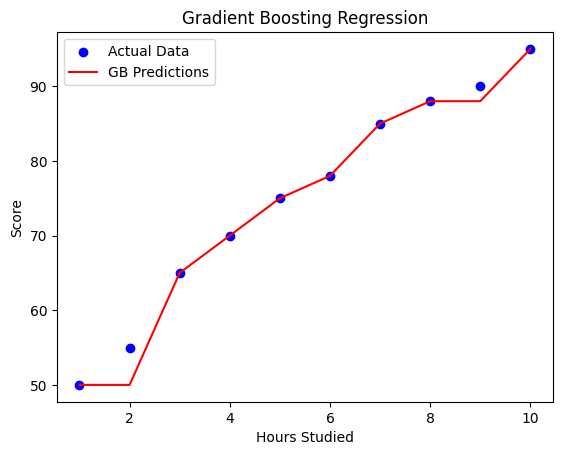

In [12]:
# Plot dataset and predictions
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, model.predict(X), color='red', label='GB Predictions')
plt.xlabel("Hours Studied")
plt.ylabel("Score")
plt.title("Gradient Boosting Regression")
plt.legend()
plt.show()

### Gradient Boosting Classification Example

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [15]:
# Create a small synthetic dataset
data = {
    "hours_studied": [1,2,3,4,5,6,7,8,9,10, 2,3,4,5,6],
    "sleep_hours":   [8,7,6,6,5,5,4,4,3,3, 7,6,5,4,3],
    "assignments_done": [0,0,1,1,2,2,3,3,4,4, 1,2,2,3,3],
    "passed":        [0,0,0,1,1,1,1,1,1,1, 0,0,1,1,1]  # Target
}

df = pd.DataFrame(data)
df

,hours_studied,sleep_hours,assignments_done,passed
0,1,8,0,0
1,2,7,0,0
2,3,6,1,0
3,4,6,1,1
4,5,5,2,1
5,6,5,2,1
6,7,4,3,1
7,8,4,3,1
8,9,3,4,1
9,10,3,4,1


In [16]:
X = df[["hours_studied", "sleep_hours", "assignments_done"]]
y = df["passed"]

In [ ]:
#Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 12
Test size: 3


In [ ]:
#Train Gradient Boosting Classifier
clf = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

clf.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [ ]:
#Predictions and Evaluation
predictions = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))
print("\nClassification Report:\n", classification_report(y_test, predictions))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, predictions))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3


Confusion Matrix:
 [[2 0]
 [0 1]]


In [ ]:
#Feature Importance
importance = clf.feature_importances_
for i, col in enumerate(X.columns):
    print(f"{col}: {importance[i]:.4f}")

hours_studied: 1.0000
sleep_hours: 0.0000
assignments_done: 0.0000


In [ ]:
#Predict New Students

new_students = pd.DataFrame({
    "hours_studied": [3,7,5],
    "sleep_hours": [6,4,5],
    "assignments_done": [1,3,2]
})

pred_classes = clf.predict(new_students)
pred_proba = clf.predict_proba(new_students)

for i, student in new_students.iterrows():
    print(f"Student {i+1}: Predicted class = {pred_classes[i]}, Probability = {pred_proba[i]}")

Student 1: Predicted class = 0, Probability = [9.99968371e-01 3.16291142e-05]
Student 2: Predicted class = 1, Probability = [1.11843085e-05 9.99988816e-01]
Student 3: Predicted class = 1, Probability = [1.11843085e-05 9.99988816e-01]
